In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df = df.dropna(subset=["TotalCharges"])

In [10]:
df.isnull().sum()
df.shape

(7032, 21)

In [11]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

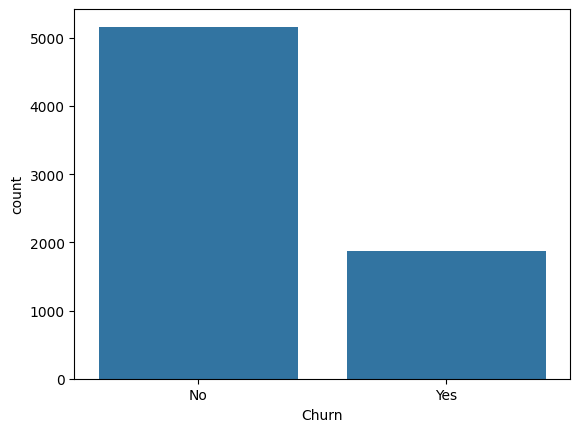

In [13]:
sns.countplot(x="Churn", data=df)
plt.show()

In [14]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


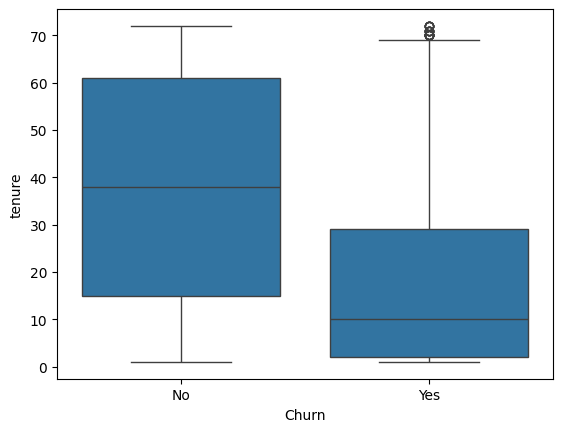

In [15]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

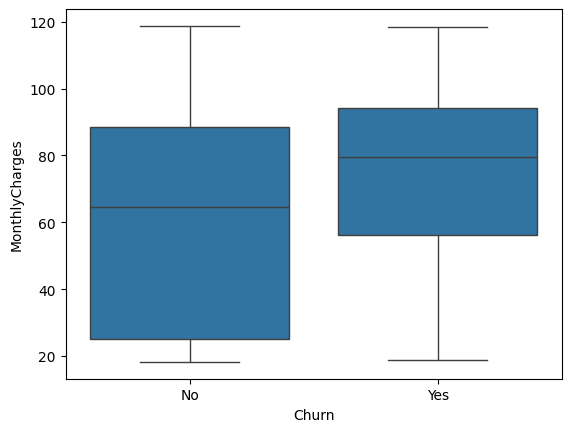

In [16]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

In [20]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

categorical_cols = df.select_dtypes(include="object").columns.drop("customerID")

for col in categorical_cols:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df["Churn"], normalize="index"))


gender
Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046

Partner
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171

Dependents
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312

PhoneService
Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475

MultipleLines
Churn                   No       Yes
MultipleLines                       
No                0.749188  0.250812
No phone service  0.750000  0.250000
Yes               0.713515  0.286485

InternetService
Churn                  No       Yes
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.418928
No               0.925658  0.074342

OnlineSecurity
Churn                      No       Yes
OnlineSecurity              

In [22]:
categorical_cols = [
    col for col in df.select_dtypes(include="object").columns
    if col != "customerID"
]

In [26]:
for col in categorical_cols:
    if df[col].nunique() < 20:  # only low-cardinality
        print(f"\n{col}")
        ct = pd.crosstab(df[col], df["Churn"], normalize="index")
        print(ct.to_string())


gender
Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046

Partner
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171

Dependents
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312

PhoneService
Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475

MultipleLines
Churn                   No       Yes
MultipleLines                       
No                0.749188  0.250812
No phone service  0.750000  0.250000
Yes               0.713515  0.286485

InternetService
Churn                  No       Yes
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.418928
No               0.925658  0.074342

OnlineSecurity
Churn                      No       Yes
OnlineSecurity              

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [18]:
import importlib
import src.feature_engineering as fe
importlib.reload(fe)

<module 'src.feature_engineering' from 'd:\\ML-PROJECTS\\telecom_churn_project\\src\\feature_engineering.py'>

In [ ]:
from src.data_preprocessing import load_and_clean_data
from src.feature_engineering import transform_features
from src.model_training import prepare_data, split_data, train_model, evaluate_model

df = load_and_clean_data("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = transform_features(df)

X, y = prepare_data(df)

X_train, X_test, y_train, y_test = split_data(X, y)

model = train_model(X_train, y_train)
evaluate_model(model, X_test, y_test)

ValueError: could not convert string to float: 'Male'